# Hotel Reservation Chatbot (v1)
- this version wont remember anything 

### install required packages

In [ ]:
%pip install langchain langchain_community langchain_openai langgraph

### import required packages

In [2]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

### create llm

In [3]:
# load all keys from .env file
load_dotenv()

# create llm object
llm = ChatOpenAI(model="gpt-5", temperature=1.0)

### configure the prompts

In [4]:
# MessagesState contains a key called as "messages" which is of type a list
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

# System message for Conversational Agent
sys_msg_conversation = SystemMessage(content="""

  Role: You are the Conversation Coordinator for a hotel chain’s customer support system. Your role is to manage the flow of the conversation with the guest and decide whether to handle the request yourself or route the conversation to a specialized agent based on the user’s needs.

  Primary Tasks:

  Engage with the user: Start the conversation politely and ask how you can assist them.
  Identify the nature of the request: Listen to the guest’s inquiry and determine if it’s a general question, booking-related, issue resolution, or any other category that might require specialized handling.
  Maintain a friendly and helpful tone: Always aim for a customer-friendly and empathetic response. Ensure the guest feels heard and cared for, regardless of whether they are routed to another agent or assisted by you.

  """)

# Agent node
def conversation_assistant(state: MessagesState) -> MessagesState:
  """
  Conversation Assistant Agent

  Args:
    state (MessagesState): The current state of the conversation.

  Returns:
    MessagesState: The updated state of the conversation.
  """
  messages = state["messages"]
  return {"messages": [llm.invoke([sys_msg_conversation] + messages)]}

### create a graph and configure it

In [5]:
from langgraph.graph import START, END, StateGraph

# Graph builder
builder = StateGraph(MessagesState)

# add a node to start conversation
builder.add_node("conversation_assistant", conversation_assistant)

# add the required edges
builder.add_edge(START, "conversation_assistant")
builder.add_edge("conversation_assistant", END)
react_graph = builder.compile()

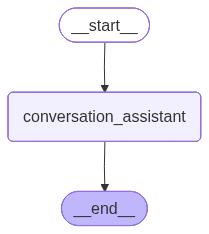

In [6]:
# Draw the graph
from IPython.display import Image, display
png = react_graph.get_graph().draw_mermaid_png()
display(Image(png))

### invoke the graph

In [11]:
from langchain_core.messages import HumanMessage

# user input
input_query = "double room in pune"

# call the graph with the input
events = react_graph.stream(
     {"messages": [HumanMessage(content=input_query)]}, stream_mode="values",
)

# iterate over the messages
for event in events:
   event["messages"][-1].pretty_print()
   message_content= event["messages"][-1].content
   if "Answer:" in message_content:
      final_answer=message_content.split("Answer:",1)[1].strip()

================================ Human Message =================================

double room in pune
================================== Ai Message ==================================

Hello! I’d be happy to help you book a double room in Pune. Could you share a few details so I can check availability and rates for our Pune hotels?

- Check-in and check-out dates (are your dates flexible?)
- Number of guests (adults and children)
- Bed preference: 1 double/queen/king bed or 2 twin beds
- Preferred area (e.g., near the airport/Viman Nagar, Koregaon Park, Hinjewadi IT Park, Baner/Wakad) or any landmark
- Budget per night and meal plan (room only or with breakfast)
- Any special requests (non‑smoking, early check‑in/late check‑out, accessibility needs)

Once I have this, I can share the best options and prices, or if you prefer, I can connect you to a reservations specialist to finalize the booking.
